# Logistic Regression

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [22]:
frogs = pd.read_csv("frogs.csv")
print(frogs.head())

   pres.abs  northing  easting  altitude  distance  NoOfPools  NoOfSites  \
0         1       115     1047      1500       500        232          3   
1         1       110     1042      1520       250         66          5   
2         1       112     1040      1540       250         32          5   
3         1       109     1033      1590       250          9          5   
4         1       109     1032      1590       250         67          5   

       avrain   meanmin    meanmax  
0  155.000000  3.566667  14.000000  
1  157.666667  3.466667  13.800000  
2  159.666667  3.400000  13.600000  
3  165.000000  3.200000  13.166667  
4  165.000000  3.200000  13.166667  


In this dataset, 212 sites of the Snowy Mountain area of New South Wales, Australia were surveyed. The variables are 
1.   pres.abs -- 0/1 indicates whether frogs were found.
2.   easting  -- distance (in meters) east of a fixed reference point
3.   northing -- distance (in meters) north of the reference point
4.   altitude -- altitude in meters
5.   distance -- distance in meters to nearest extant population
6.   NoOfPools-- number of potential breeding pools
7.   NoOfSites-- number of potential breeding sites within a 2 km radius
8.   avrain   -- mean rainfall for Spring period
9.   meanmin  -- mean minimum Spring temperature
10.  meanmax  -- mean maximum Spring temperature

We wish to explain frog distribution as a function of the other variables. 


In [23]:
y = frogs["pres.abs"].astype(int)

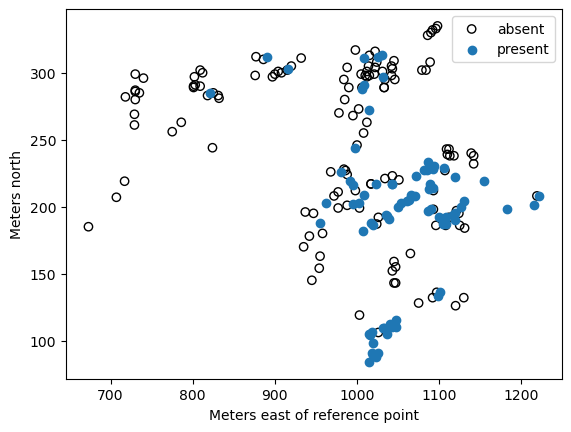

In [24]:
plt.figure()
absent = frogs["pres.abs"] == 0
present = frogs["pres.abs"] == 1
plt.scatter(frogs.loc[absent, "easting"], frogs.loc[absent, "northing"],
            marker="o", facecolors="none", edgecolors="black", label="absent")
plt.scatter(frogs.loc[present, "easting"], frogs.loc[present, "northing"],
            marker="o", label="present")
plt.xlabel("Meters east of reference point")
plt.ylabel("Meters north")
plt.legend()
plt.show()

In the above plot, the filled points are for sites where frogs are found. 

Next we look at plots for the remaining variables. 

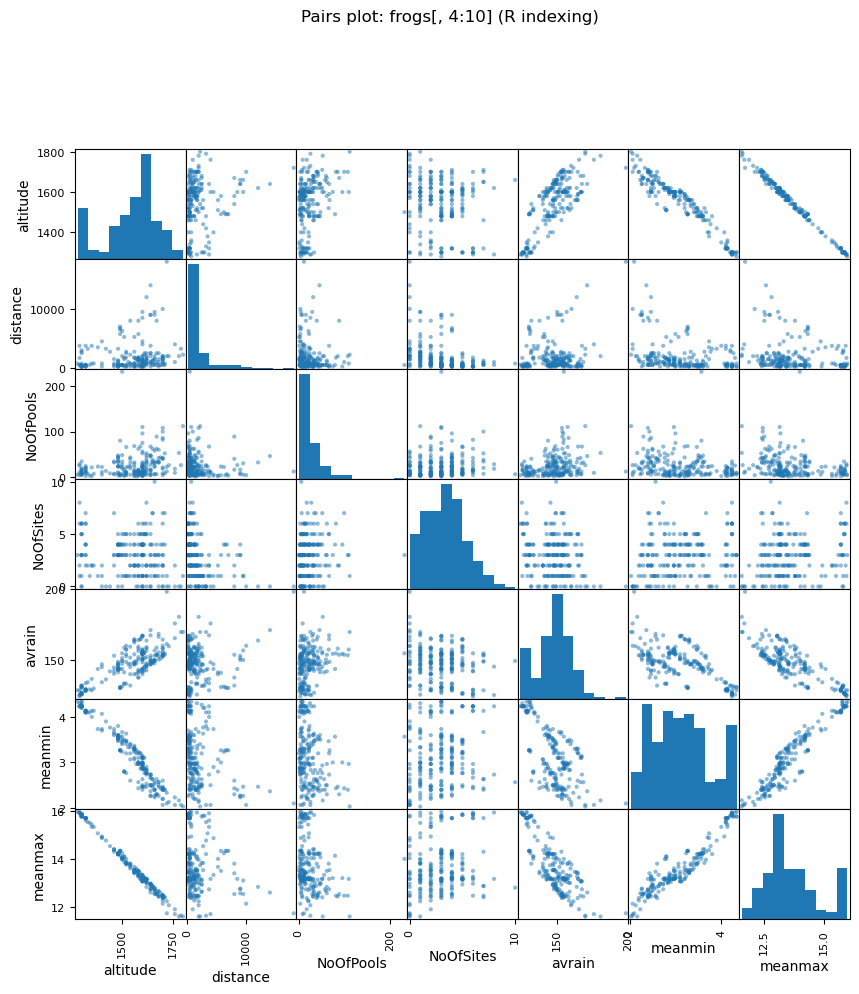

In [25]:
cols_pairs = frogs.columns[3:10]   # 4th..10th columns
from pandas.plotting import scatter_matrix
scatter_matrix(frogs[cols_pairs], figsize=(10, 10), diagonal="hist")
plt.suptitle("Pairs plot: frogs[, 4:10] (R indexing)", y=1.02)
plt.show()

distance summary:
 count      212.000000
mean      1932.547170
std       2588.596414
min        250.000000
25%        500.000000
50%       1000.000000
75%       2000.000000
max      18000.000000
Name: distance, dtype: float64 



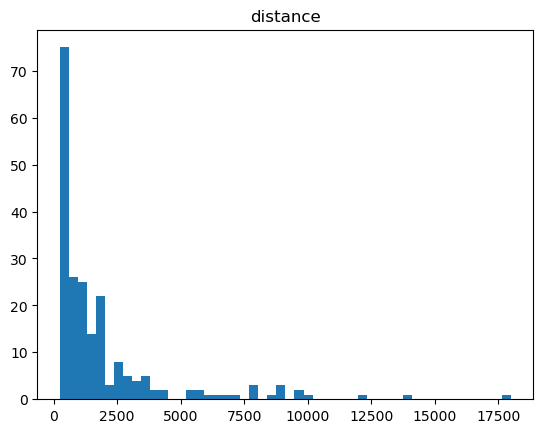

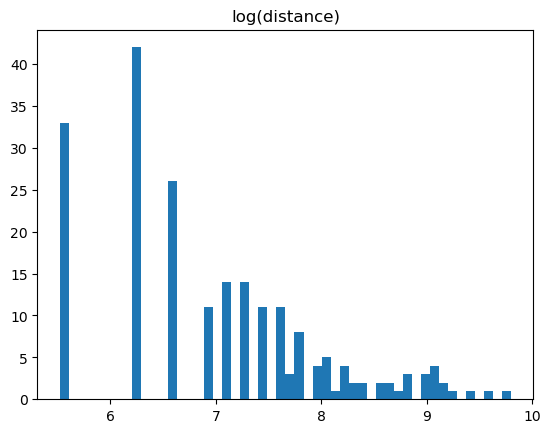

NoOfPools summary:
 count    212.000000
mean      25.113208
std       26.562747
min        1.000000
25%        8.000000
50%       18.000000
75%       32.000000
max      232.000000
Name: NoOfPools, dtype: float64 



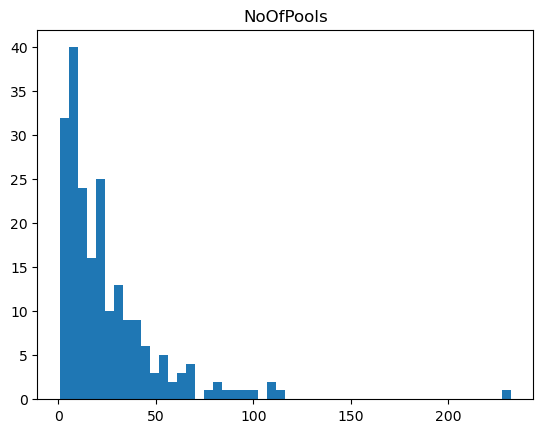

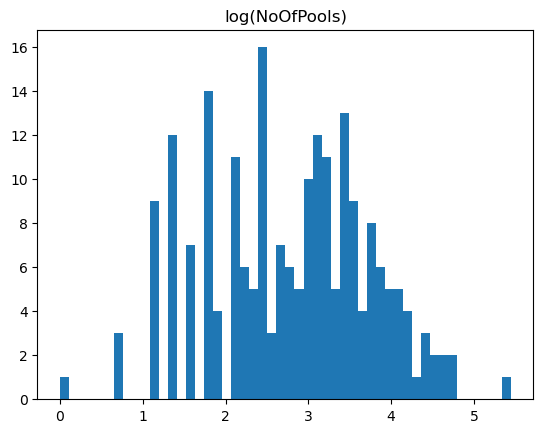

In [26]:
def quick_summary(s: pd.Series):
    return s.describe()

print("distance summary:\n", quick_summary(frogs["distance"]), "\n")
plt.figure()
plt.hist(frogs["distance"].dropna(), bins=50)
plt.title("distance")
plt.show()

plt.figure()
plt.hist(np.log(frogs["distance"].dropna()), bins=50)
plt.title("log(distance)")
plt.show()

print("NoOfPools summary:\n", quick_summary(frogs["NoOfPools"]), "\n")
plt.figure()
plt.hist(frogs["NoOfPools"].dropna(), bins=50)
plt.title("NoOfPools")
plt.show()

plt.figure()
plt.hist(np.log(frogs["NoOfPools"].dropna()), bins=50)
plt.title("log(NoOfPools)")
plt.show()


Now we fit the logistic regression model. 

In [27]:
X = pd.DataFrame({
    "altitude": frogs["altitude"],
    "log_distance": np.log(frogs["distance"]),
    "log_NoOfPools": np.log(frogs["NoOfPools"]),
    "NoOfSites": frogs["NoOfSites"],
    "avrain": frogs["avrain"],
    "meanmin": frogs["meanmin"],
    "meanmax": frogs["meanmax"],
})

import statsmodels.api as sm
X = sm.add_constant(X)
logistic_model = sm.GLM(y, X, family=sm.families.Binomial()).fit()

print(logistic_model.summary())
print(logistic_model.params.values)

                 Generalized Linear Model Regression Results                  
Dep. Variable:               pres.abs   No. Observations:                  212
Model:                            GLM   Df Residuals:                      204
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -98.812
Date:                Wed, 04 Mar 2026   Deviance:                       197.62
Time:                        13:53:30   Pearson chi2:                     234.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3219
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            40.8988    132.663      0.308

Below we check that the standard errors are the same as those derived using the formula from class (posterior normal approximation). 

In [28]:
beta_hat = logistic_model.params.values
p_hat = logistic_model.fittedvalues.values
W = p_hat * (1.0 - p_hat)
Xm = X.values
Hess = -(Xm.T @ (W[:, None] * Xm)) #this is the -(X^T W X) matrix
cov_mat = np.linalg.inv(-Hess)

In [29]:
print(np.sqrt(np.diag(cov_mat)))
print(logistic_model.bse.values)

[1.32663132e+02 3.86605641e-02 2.55376843e-01 2.16244670e-01
 1.07422718e-01 5.99956244e-02 1.54269086e+00 4.83967039e+00]
[1.32663131e+02 3.86605637e-02 2.55376842e-01 2.16244669e-01
 1.07422717e-01 5.99956240e-02 1.54269084e+00 4.83967035e+00]


The whole covariance matrix is also the same as that reported by statsmodels, as can be checked below. 

In [30]:
print(cov_mat)
print(logistic_model.cov_params())

[[ 1.75995066e+04 -5.09091624e+00 -1.80812332e+00  1.34222315e+00
   1.76974442e+00 -6.37982424e+00 -1.70778721e+01 -6.37602960e+02]
 [-5.09091624e+00  1.49463922e-03  2.47666303e-04 -4.26796200e-04
  -6.18066803e-04  1.68935776e-03  1.05025245e-02  1.82521807e-01]
 [-1.80812332e+00  2.47666303e-04  6.52173322e-02  9.06400961e-03
   1.24731516e-02  1.87404726e-03  2.84660381e-02  4.04222324e-02]
 [ 1.34222315e+00 -4.26796200e-04  9.06400961e-03  4.67617571e-02
  -5.24288226e-04 -6.02997735e-04  6.50595329e-02 -7.27555346e-02]
 [ 1.76974442e+00 -6.18066803e-04  1.24731516e-02 -5.24288226e-04
   1.15396402e-02  1.94369363e-04  7.98098030e-04 -7.04628249e-02]
 [-6.37982424e+00  1.68935776e-03  1.87404726e-03 -6.02997735e-04
   1.94369363e-04  3.59947495e-03 -2.57654789e-02  2.41435448e-01]
 [-1.70778721e+01  1.05025245e-02  2.84660381e-02  6.50595329e-02
   7.98098030e-04 -2.57654789e-02  2.37989509e+00 -2.40260634e-01]
 [-6.37602960e+02  1.82521807e-01  4.04222324e-02 -7.27555346e-02
  -

## Newton's method for calculating the MLE

As discussed in the notes, Newton's algorithm for calculating the MLE in logistic regression works as follows. Start with an initial value $\beta^{(0)}$. For $m = 0, 1, 2, \dots$, the current iterate $\beta^{(m)}$ is converted to $\beta^{(m+1)}$ in the following way: 
1. Calculate: 
\begin{align*}
   p_i = \frac{\exp(x_i^T \beta^{(m)})}{1 + \exp(x_i^T \beta^{(m)})}
\end{align*}
for $i = 1, \dots, n$. 
2. Let $W$ be the diagonal matrix with entries $p_i (1 - p_i)$. 
3. Define 
\begin{align*}
   Z = X \beta^{(m)} + W^{-1} (y - p)
\end{align*}
4. Take $\beta^{(m+1)} = (X^T W X)^{-1} X^T W Z$. 
This algorithm usually converges very quickly (in just a few iterations). 

The following code implements these iterates. 

In [31]:
p = X.shape[1] #this includes intercept
beta = np.zeros(p) #this is the initialization
Xm = X.values
yvec = y.values

for it in range(5):
    eta = Xm @ beta
    pvec = 1.0 / (1.0 + np.exp(-eta))
    wts = pvec * (1.0 - pvec)
    z = np.log(pvec/ (1.0 - pvec)) + (yvec - pvec)/wts
    XtW = Xm.T * wts
    beta_new = np.linalg.solve(XtW @ Xm, XtW @ z)
    beta = beta_new
    print(beta)

print(beta_hat)


[ 1.19672935e+02 -3.28640311e-02 -4.81584327e-01  3.41646205e-01
  1.54487737e-02 -3.04652355e-02  2.79412875e+00 -5.20689632e+00]
[ 9.51921077e+01 -2.40443158e-02 -6.62407599e-01  5.08556070e-01
  1.11109668e-02 -2.07156474e-02  4.32723443e+00 -4.82983840e+00]
[ 5.22965134e+01 -1.02910252e-02 -7.44234193e-01  5.66225140e-01
  1.46637380e-03 -9.33557841e-03  5.13416708e+00 -3.53295420e+00]
[ 4.12853255e+01 -6.77085893e-03 -7.58904662e-01  5.72602026e-01
 -8.30003653e-04 -6.87596854e-03  5.29944041e+00 -3.18531327e+00]
[ 4.08992169e+01 -6.64784594e-03 -7.59304031e-01  5.72726833e-01
 -8.97883811e-04 -6.79308697e-03  5.30478275e+00 -3.17297113e+00]
[ 4.08988167e+01 -6.64771908e-03 -7.59304375e-01  5.72726929e-01
 -8.97944859e-04 -6.79299948e-03  5.30478801e+00 -3.17295825e+00]


Here the algorithm seems to have converged after just 5 iterations. 